see skr meeting notes 2026-01-20 & sim master note of same day

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

%load_ext autoreload
%autoreload 2

2026-01-20 14:50:29.281660: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 14:50:29.285023: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
local=True
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=2,#cores per slurm job
        memory="32G",#memory per slurm job
        processes=1,#dask workers per slurm jobTrueT
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=4:00:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [8]:
from pathlib import Path

In [9]:
data_root=Path("/nfs/roberts/project/pi_skr2/shared/tabula_data")

sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'pow_sim_2026-01-03', loading.


In [4]:
import pandas as pd

In [5]:
df=sim.ground_truth

ref = df[df["cre_id"] == "reference"].set_index("cell_type")["true_mean"]

diffs = (
    df[df["cre_id"] != "reference"]
    .join(ref, on="cell_type", rsuffix="_ref")
    .assign(diff=lambda x: (x["true_mean"] - x["true_mean_ref"]).abs())
)

summary = (
    diffs.groupby("cell_type")["diff"]
        .apply(lambda s: pd.Series(sorted(s.unique())[:2], index=["min_diff", "second_unique_min_diff"]))
        .reset_index()
)

print(summary)

                  cell_type                 level_1       diff
0            Cardiomyocytes                min_diff   0.000000
1            Cardiomyocytes  second_unique_min_diff  14.641888
2   EpiblastPrimitiveStreak                min_diff   0.000000
3   EpiblastPrimitiveStreak  second_unique_min_diff  14.641888
4        ExEndodermParietal                min_diff   0.000000
5        ExEndodermParietal  second_unique_min_diff  14.641888
6        ExEndodermVisceral                min_diff   0.000000
7        ExEndodermVisceral  second_unique_min_diff  14.641888
8        Haematoendothelial                min_diff   0.000000
9        Haematoendothelial  second_unique_min_diff  14.641888
10                 Mesoderm                min_diff   0.000000
11                 Mesoderm  second_unique_min_diff  14.641888
12       NeuroectodermBrain                min_diff   0.000000
13       NeuroectodermBrain  second_unique_min_diff  14.641888
14     NeuroectodermRostral                min_diff   0

In [ ]:
primordial=scm.ortho.load(client,data_root/"shendure","shendure_ortho_20260306")

In [11]:
primordial

In [25]:
import numpy as np

In [33]:
nbs=[np.ravel(x.result()["mu"].values) for x in primordial.by_cre_parameters.nb.values()]

In [38]:
nbs=np.concatenate(nbs)

In [37]:
minp=scm.SHENDURE_BOUNDS.reference_activity

In [67]:
gaps=np.abs(nbs-minp)

In [68]:
gaps

array([0.20443007, 2.43451475, 0.77342272, ..., 0.04454623, 0.04182754,
       0.13234841])

In [69]:
gaps=np.sort(gaps)
gaps = gaps[~np.isnan(gaps)]
gaps

array([1.10293353e-04, 1.72571891e-04, 2.27501190e-04, ...,
       2.32153844e+02, 2.85916390e+02, 3.70449611e+02])

In [70]:
import seaborn as sns

<Axes: ylabel='Count'>

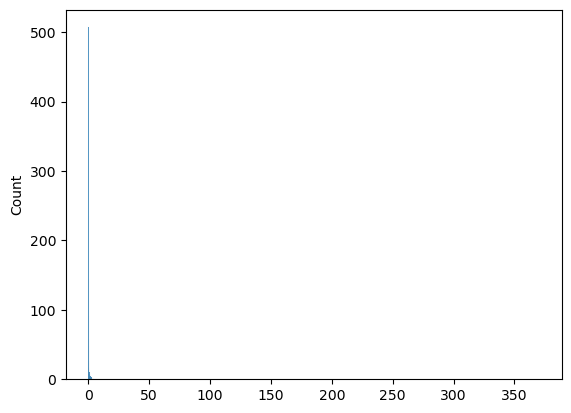

In [71]:
sns.histplot(gaps)

In [72]:
sum(gaps<14.6)/len(gaps)

0.9808350444900753

In [73]:
gaps_signed=nbs-minp
gaps_signed = gaps_signed[~np.isnan(gaps_signed)]

In [74]:
np.mean(gaps_signed)

2.1399389291413238

In [75]:
gaps_signed

array([0.20443007, 2.43451475, 0.77342272, ..., 0.04454623, 0.04182754,
       0.13234841])

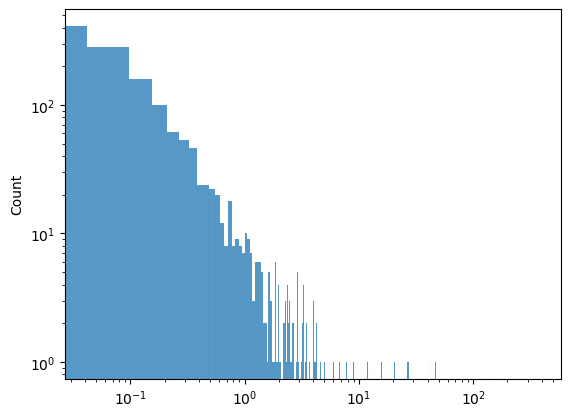

In [77]:
ax = sns.histplot(gaps_signed)

ax.set_xscale("log")
ax.set_yscale("log")